# Actividad 08 · Agrupamiento jerárquico
**Machine Learning I — Unidad II**  
**Autora:** Jaqueline Rocio Ramos Vargas  
**Modalidad:** individual

## Objetivo y entregables
Comprender cómo cambia una jerarquía al modificar el criterio de enlace (*linkage*) y aplicarla a texto, clientes e imágenes.

| Apartado | Solución | Puntos |
|---|---|---:|
| 1. Texto | 20 Newsgroups, cuatro linkages, métricas, dendrogramas y términos | 6 |
| 2. Clientes | Datos sintéticos, cuatro linkages, selección de k y perfiles | 6 |
| 3. Imágenes | Dos fotografías, tres linkages y conectividad espacial | 6 |
| 4. Resumen | README generado con resultados reales y referencias | 2 |

**Uso en Colab:** subir este `.ipynb`, usar CPU y seleccionar **Entorno de ejecución → Ejecutar todas**. Solo el texto requiere descargar datos; incluye un origen alternativo verificado por SHA256. Al final se genera un ZIP con el resumen y las figuras. El notebook conserva las salidas de la ejecución entregada.

**Alcance:** 2 000 documentos (100 de cada una de las 20 categorías), 500 clientes simulados y fotografías reducidas a 96 × 64 píxeles. No se requiere Kaggle, GPU ni claves de acceso.

## 0. Fundamento y protocolo
El algoritmo aglomerativo comienza con un grupo por observación y fusiona grupos hasta formar una jerarquía. Un corte del árbol produce una partición con $k$ grupos.

| Linkage | Regla de fusión | Comportamiento habitual |
|---|---|---|
| Single | Menor distancia entre dos puntos de los grupos | Puede formar cadenas y grupos desequilibrados |
| Complete | Mayor distancia entre dos puntos de los grupos | Favorece grupos de diámetro reducido |
| Average | Promedio de distancias entre los grupos | Compromiso entre single y complete |
| Ward | Menor incremento de suma de cuadrados interna | Favorece grupos compactos; requiere distancia euclídea |

Para Ward, el costo de fusionar $A$ y $B$ es proporcional a:
$$\Delta(A,B)=\frac{|A||B|}{|A|+|B|}\|\mu_A-\mu_B\|^2.$$
Las alturas de Ward y de los otros criterios **no tienen la misma interpretación numérica**. Los dendrogramas muestran las últimas fusiones del árbol real; una hoja contraída puede contener varias observaciones.

**Criterios definidos antes de ejecutar:**
- **Texto:** mayor ARI a $k=20$; desempate por V-measure. Es una comparación exploratoria con categorías conocidas, no una evaluación sobre documentos nuevos.
- **Clientes:** mayor silhouette entre $k=2,\ldots,8$ y cuatro linkages; desempate por menor Davies–Bouldin y menor $k$. Las etiquetas sintéticas se usan solo después para evaluar.
- **Imágenes:** comparar reconstrucción RGB a igual $k$ y observar fronteras. El menor MSE mide fidelidad del color, no exactitud semántica. No hay máscaras de referencia en estas fotografías.

**Métricas:** ARI (1 = coincidencia perfecta; cerca de 0 = nivel esperado por azar), V-measure (0–1, mayor es mejor), silhouette (−1 a 1, mayor es mejor) y Davies–Bouldin (menor es mejor). Los identificadores de cluster son arbitrarios; no se calcula accuracy comparándolos directamente con las clases.

Fuentes: [clustering jerárquico](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering), [API AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html).

### Dependencias
El notebook usa bibliotecas habituales de Colab. Si faltan, ejecutar en una celda:
```python
%pip install "scikit-learn>=1.6,<2" "numpy>=1.24,<3" "pandas>=2,<3" "scipy>=1.10,<2" "matplotlib>=3.7,<4" "Pillow>=10,<13"
```
Si se actualiza una biblioteca ya importada, reiniciar la sesión y ejecutar todo. Las versiones exactas utilizadas se guardan en `resultados/entorno.json`.

In [1]:
from pathlib import Path
from time import perf_counter
import json, re, hashlib, platform, warnings, shutil
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from scipy.cluster.hierarchy import dendrogram
from scipy.ndimage import label as connected_label
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import fetch_20newsgroups, make_blobs, load_sample_image
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.image import grid_to_graph
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (adjusted_rand_score, v_measure_score,
                             silhouette_score, davies_bouldin_score)
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown

SEED = 42
LINKAGES = ['ward', 'complete', 'average', 'single']
OUT = Path('resultados')
FIG = OUT / 'figuras'
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 160,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10, 'axes.titlesize': 12})
pd.set_option('display.max_colwidth', 95)
# Limitar BLAS evita sobrecarga en máquinas con muchos núcleos.
threadpool_guard = threadpool_limits(limits=2)
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
            'Pillow': PIL.__version__, 'seed': SEED}
(OUT / 'entorno.json').write_text(json.dumps(versions, indent=2), encoding='utf-8')
display(versions)

{'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.8', 'Pillow': '12.3.0', 'seed': 42}

In [2]:
def savefig(name):
    plt.tight_layout(pad=1.4, h_pad=2.2)
    plt.savefig(FIG / name, bbox_inches='tight')
    plt.show()
    plt.close()

def to_linkage(model):
    """Convertir el árbol ajustado de sklearn a formato SciPy, sin reentrenar."""
    n = len(model.labels_)
    counts = np.zeros(len(model.children_))
    for i, children in enumerate(model.children_):
        counts[i] = sum(1 if child < n else counts[child - n] for child in children)
    assert len(model.children_) == n - 1, 'Se necesita el árbol completo.'
    return np.column_stack([model.children_, model.distances_, counts]).astype(float)

def scores(X, labels, reference=None):
    sizes = np.bincount(labels)
    result = {'k': len(sizes), 'silhouette': silhouette_score(X, labels),
              'davies_bouldin': davies_bouldin_score(X, labels),
              'min_n': int(sizes.min()), 'max_n': int(sizes.max()),
              'max_proporcion': float(sizes.max() / len(labels))}
    if reference is not None:
        result.update(ARI=adjusted_rand_score(reference, labels),
                      V_measure=v_measure_score(reference, labels))
    return result

def table_md(df, digits=4):
    """Tabla Markdown sin depender de tabulate."""
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            return f'{x:.{digits}f}'
        return str(x).replace('|', '/').replace('\n', ' ')
    headers = [str(c) for c in df.columns]
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---']*len(headers)) + ' |']
    lines += ['| ' + ' | '.join(fmt(v) for v in row) + ' |' for row in df.itertuples(index=False, name=None)]
    return '\n'.join(lines)

text_results = None
text_findings = []
text_profiles = pd.DataFrame()
text_status = 'pendiente'

## 1. Clustering jerárquico de texto — 20 Newsgroups
Se usa el subconjunto `train` del corpus real. Se retiran cabeceras, pies y citas para reducir pistas ajenas al contenido. Se descartan documentos muy cortos y duplicados exactos después de normalizar espacios; se toma una muestra reproducible de 100 documentos por categoría.

La estratificación y $k=20$ aprovechan información del conjunto para diseñar la demostración. **Las categorías no entran como variables al clustering**. Se conservan únicamente para muestrear y evaluar la correspondencia temática.

Representación: **TF–IDF → SVD de 100 dimensiones → normalización L2**. Los cuatro métodos reciben exactamente la misma matriz y distancia euclídea; así se aísla el efecto del linkage. En vectores unitarios, $d_{euclídea}^2=2(1-\cos\theta)$, aunque agregar distancias de manera distinta no hace equivalentes todos los linkages. La reducción pierde información; se informa su varianza explicada.

El uso de 2 000 documentos limita el costo cuadrático habitual del clustering sin conectividad. No se afirma que esta muestra equivalga a procesar todo el corpus.

Fuentes: [20 Newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html), [representación TF–IDF/LSA para agrupar textos](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html).

In [3]:
N_PER_CLASS = 100
N_COMPONENTS = 100
text_data = None
# El origen alternativo contiene exactamente el mismo archivo: se valida SHA256.
from urllib.request import urlopen
from sklearn.datasets import get_data_home
DATA_HOME = Path(get_data_home(data_home='datos_cache'))
ARCHIVE_SHA256 = '8f1b2514ca22a5ade8fbb9cfa5727df95fa587f4c87b786e15c759fa66d95610'
SOURCE_ALTERNATIVE = 'https://people.csail.mit.edu/jrennie/20Newsgroups/20news-bydate.tar.gz'

def load_newsgroups():
    kwargs = dict(subset='train', remove=('headers', 'footers', 'quotes'),
                  shuffle=True, random_state=SEED, data_home=str(DATA_HOME),
                  n_retries=1, delay=1)
    try:
        return fetch_20newsgroups(**kwargs)
    except Exception as primary_error:
        print(f'Descarga principal no disponible: {type(primary_error).__name__}. Probando archivo original.')
        with urlopen(SOURCE_ALTERNATIVE, timeout=60) as response:
            archive = response.read()
        if hashlib.sha256(archive).hexdigest() != ARCHIVE_SHA256:
            raise ValueError('El archivo no coincide con el SHA256 oficial; no se utilizará.')
        archive_path = DATA_HOME / '20news_home' / '20news-bydate.tar.gz'
        archive_path.parent.mkdir(parents=True, exist_ok=True)
        archive_path.write_bytes(archive)
        # sklearn >=1.6 reutiliza el archivo local tras comprobar su hash.
        return fetch_20newsgroups(**kwargs)

try:
    text_data = load_newsgroups()
    text_status = 'datos disponibles'
    print(f'Documentos originales: {len(text_data.data):,}; categorías: {len(text_data.target_names)}')
except Exception as exc:
    # No sustituir el corpus real por textos inventados ni fabricar resultados.
    text_status = f'NO EJECUTADO: descarga fallida ({type(exc).__name__}: {exc})'
    print(text_status)
    print('En Colab, habilitar internet y volver a ejecutar todas las celdas.')
    print('Clientes e imágenes pueden ejecutarse aunque falle esta descarga.')

Documentos originales: 11,314; categorías: 20


In [4]:
if text_data is not None:
    seen, valid = set(), []
    for i, document in enumerate(text_data.data):
        normalized = ' '.join(document.lower().split())
        if len(re.findall(r'[a-zA-Z]{2,}', normalized)) < 20:
            continue
        digest = hashlib.sha256(normalized.encode('utf-8')).hexdigest()
        if digest in seen:
            continue
        seen.add(digest)
        valid.append(i)
    valid = np.array(valid)
    rng_text = np.random.default_rng(SEED)
    selected = []
    for class_id in range(len(text_data.target_names)):
        candidates = valid[text_data.target[valid] == class_id]
        assert len(candidates) >= N_PER_CLASS, 'Reducir N_PER_CLASS.'
        selected.extend(rng_text.choice(candidates, N_PER_CLASS, replace=False))
    selected = rng_text.permutation(selected)
    documents = [text_data.data[i] for i in selected]
    y_text = text_data.target[selected]
    vectorizer = TfidfVectorizer(stop_words='english', min_df=3, max_df=0.70,
                                max_features=15000, sublinear_tf=True,
                                token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b')
    tfidf = vectorizer.fit_transform(documents)
    # Vectores vacíos no definen una dirección; documentar cualquier descarte.
    keep = np.asarray(tfidf.getnnz(axis=1)).ravel() > 0
    selected, y_text, tfidf = selected[keep], y_text[keep], tfidf[keep]
    documents = [d for d, use in zip(documents, keep) if use]
    svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=SEED)
    latent = svd.fit_transform(tfidf)
    assert np.all(np.linalg.norm(latent, axis=1) > 1e-12)
    X_text = normalize(latent)
    explained = float(svd.explained_variance_ratio_.sum())
    sample_hash = hashlib.sha256('\n'.join(documents).encode('utf-8')).hexdigest()
    text_audit = {'originales': len(text_data.data), 'validos': len(valid),
                  'muestra_solicitada': N_PER_CLASS * 20, 'vectores_vacios': int((~keep).sum()),
                  'muestra_final': len(X_text), 'vocabulario': tfidf.shape[1],
                  'dimensiones_svd': N_COMPONENTS, 'varianza_explicada': explained,
                  'sha256_textos_ordenados': sample_hash, 'sha256_archivo_original': ARCHIVE_SHA256}
    (OUT / 'texto_auditoria.json').write_text(json.dumps(text_audit, indent=2), encoding='utf-8')
    display(text_audit)
    display(pd.Series(y_text).value_counts().sort_index().rename_axis('clase').to_frame('n'))

{'originales': 11314, 'validos': 9986, 'muestra_solicitada': 2000, 'vectores_vacios': 0, 'muestra_final': 2000, 'vocabulario': 8020, 'dimensiones_svd': 100, 'varianza_explicada': 0.17007099664809697, 'sha256_textos_ordenados': '19b0e3e801f88adccc2ef2eaab7ca9d0af751288f488d3593b3406495c9c4b04', 'sha256_archivo_original': '8f1b2514ca22a5ade8fbb9cfa5727df95fa587f4c87b786e15c759fa66d95610'}

,n
clase,
0,100
1,100
2,100
3,100
4,100
5,100
6,100
7,100
8,100


In [5]:
if text_data is not None:
    text_models, rows = {}, []
    for method in LINKAGES:
        t0 = perf_counter()
        model = AgglomerativeClustering(n_clusters=20, linkage=method, metric='euclidean',
                                       compute_full_tree=True, compute_distances=True)
        labels = model.fit_predict(X_text)
        elapsed = perf_counter() - t0
        row = {'linkage': method, **scores(X_text, labels, y_text), 'segundos_ajuste': elapsed}
        rows.append(row)
        text_models[method] = model
    text_results = pd.DataFrame(rows).sort_values(['ARI', 'V_measure'], ascending=False).reset_index(drop=True)
    text_results.to_csv(OUT / 'texto_metricas.csv', index=False)
    display(text_results.round(4))
    best_text = text_results.iloc[0]['linkage']
    text_labels = text_models[best_text].labels_
    text_status = 'EJECUTADO'
    text_assignments = pd.DataFrame({'indice_train': selected, 'categoria': np.array(text_data.target_names)[y_text]})
    for method, model in text_models.items():
        text_assignments[method] = model.labels_
    text_assignments.to_csv(OUT / 'texto_asignaciones.csv', index=False)
    display(Markdown(f'**Mejor linkage según ARI: {best_text}.** '
                     f'ARI = {text_results.iloc[0].ARI:.4f}; V-measure = {text_results.iloc[0].V_measure:.4f}. '
                     'La conclusión se limita a esta muestra y representación.'))

,linkage,k,silhouette,davies_bouldin,min_n,max_n,max_proporcion,ARI,V_measure,segundos_ajuste
0,average,20,0.0131,3.9803,8,687,0.3435,0.1327,0.3196,0.1408
1,ward,20,0.0198,3.8967,16,600,0.3000,0.0974,0.3911,0.1419
2,complete,20,0.0063,5.7594,36,208,0.1040,0.0773,0.1894,0.2051
3,single,20,-0.0988,1.0861,1,1979,0.9895,0.0000,0.0204,0.1105


**Mejor linkage según ARI: average.** ARI = 0.1327; V-measure = 0.3196. La conclusión se limita a esta muestra y representación.

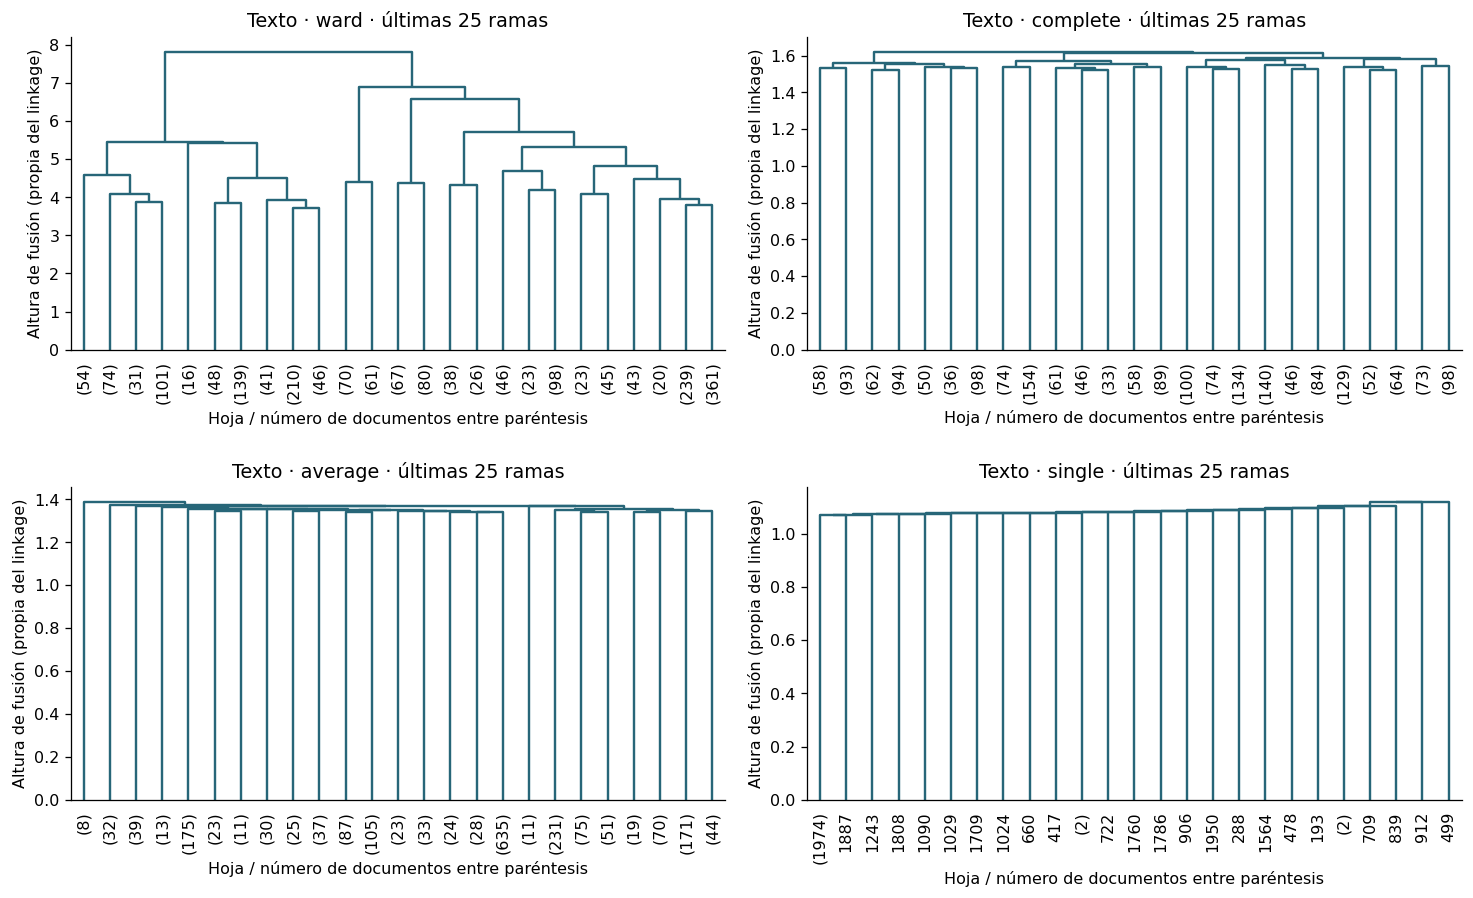

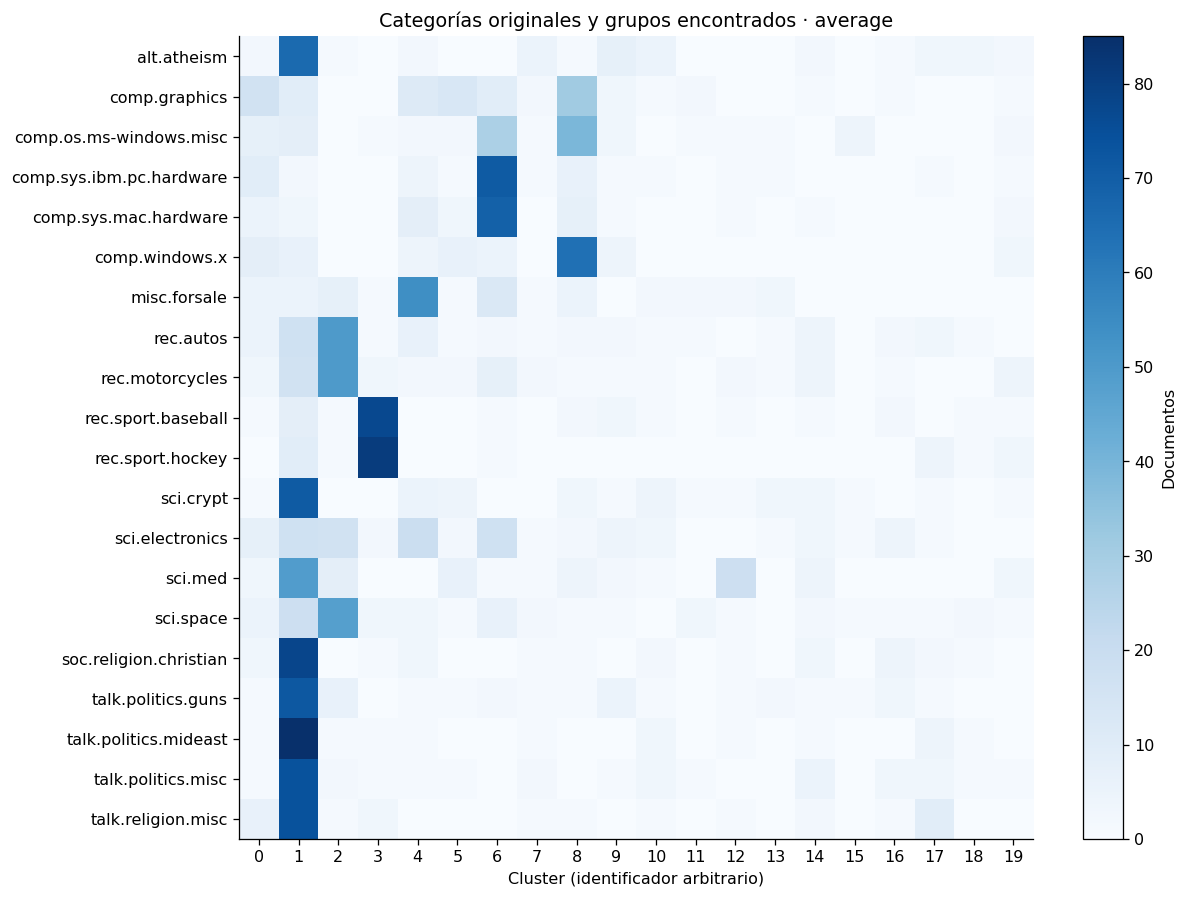

In [6]:
if text_results is not None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, method in zip(axes.ravel(), LINKAGES):
        dendrogram(to_linkage(text_models[method]), truncate_mode='lastp', p=25,
                   show_leaf_counts=True, leaf_rotation=90, ax=ax, color_threshold=0,
                   above_threshold_color='#276678')
        ax.set_title(f'Texto · {method} · últimas 25 ramas')
        ax.set_xlabel('Hoja / número de documentos entre paréntesis')
        ax.set_ylabel('Altura de fusión (propia del linkage)')
    savefig('texto_dendrogramas.png')

    contingency = pd.crosstab(pd.Series(y_text, name='Categoría'),
                              pd.Series(text_labels, name='Cluster')).reindex(index=range(20), columns=range(20), fill_value=0)
    contingency.index = text_data.target_names
    contingency.to_csv(OUT / 'texto_contingencia.csv')
    fig, ax = plt.subplots(figsize=(11, 8))
    im = ax.imshow(contingency, cmap='Blues', aspect='auto')
    ax.set_yticks(range(20), text_data.target_names)
    ax.set_xticks(range(20))
    ax.set_xlabel('Cluster (identificador arbitrario)')
    ax.set_title(f'Categorías originales y grupos encontrados · {best_text}')
    fig.colorbar(im, ax=ax, label='Documentos')
    savefig('texto_contingencia.png')

### 1.1. Interpretación de los grupos
Se describen los grupos con las palabras de mayor TF–IDF promedio, su tamaño y sus dos categorías más frecuentes. La proporción de la categoría dominante es descriptiva; no es una prueba de calidad por sí sola. Los títulos temáticos requieren leer documentos representativos antes de aplicarlos en producción.

In [7]:
if text_results is not None:
    vocabulary = vectorizer.get_feature_names_out()
    profiles = []
    for cluster_id in np.unique(text_labels):
        mask = text_labels == cluster_id
        weights = np.asarray(tfidf[mask].mean(axis=0)).ravel()
        words = vocabulary[np.argsort(weights)[-10:][::-1]]
        distribution = pd.Series(y_text[mask]).value_counts()
        leading = ', '.join(f'{text_data.target_names[c]} ({n})' for c, n in distribution.head(2).items())
        profiles.append({'cluster': int(cluster_id), 'n': int(mask.sum()),
                         'categorias_principales': leading,
                         'proporcion_dominante': float(distribution.iloc[0]/mask.sum()),
                         'terminos': ', '.join(words)})
    text_profiles = pd.DataFrame(profiles).sort_values('cluster')
    text_profiles.to_csv(OUT / 'texto_perfiles.csv', index=False)
    display(text_profiles)
    winner = text_results.iloc[0]
    text_findings = [
        f'Con {len(X_text)} documentos y k=20, {best_text} obtuvo el mayor ARI ({winner.ARI:.4f}) entre los cuatro linkages.',
        f'La representación SVD retuvo {explained:.1%} de la varianza de TF–IDF; sus 100 componentes no conservan toda la información.',
        f'El grupo más grande del ganador concentra {winner.max_proporcion:.1%} de los documentos; el más pequeño contiene {int(winner.min_n)}.']
    for method in LINKAGES:
        row = text_results.set_index('linkage').loc[method]
        text_findings.append(f'{method}: ARI={row.ARI:.4f}, silhouette={row.silhouette:.4f}, grupo mayor={row.max_proporcion:.1%}.')
    for _, row in text_profiles.sort_values('proporcion_dominante', ascending=False).head(3).iterrows():
        text_findings.append(f'Grupo {row.cluster}: {row.n} documentos; {row.categorias_principales}; términos: {row.terminos}.')
    # Interpretar coincidencias temáticas con los datos de la ejecución actual.
    for topic, categories in [
        ('deportes', ['rec.sport.hockey', 'rec.sport.baseball']),
        ('hardware', ['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']),
        ('sistemas y ventanas', ['comp.windows.x', 'comp.os.ms-windows.misc'])]:
        ids = [text_data.target_names.index(name) for name in categories]
        relevant = np.isin(y_text, ids)
        dominant_cluster = pd.Series(text_labels[relevant]).value_counts().idxmax()
        n_topic = int((relevant & (text_labels == dominant_cluster)).sum())
        n_group = int((text_labels == dominant_cluster).sum())
        text_findings.append(f'En {topic}, el grupo {dominant_cluster} contiene {n_topic} documentos de las dos categorías relacionadas, dentro de {n_group} documentos totales. Esto muestra temas amplios, no una separación perfecta de cada foro.')
    best_v = text_results.loc[text_results.V_measure.idxmax()]
    text_findings.append(f'Las métricas no coinciden: {best_v.linkage} lidera V-measure ({best_v.V_measure:.4f}); se mantiene {best_text} como ganador según el ARI definido de antemano. El ARI bajo del ganador indica correspondencia limitada, no recuperación satisfactoria de las 20 categorías.')
    single_row = text_results.set_index('linkage').loc['single']
    text_findings.append(f'Single concentra {single_row.max_proporcion:.1%} en un grupo; su Davies–Bouldin={single_row.davies_bouldin:.4f} no debe interpretarse aisladamente como superioridad temática.')
    text_findings.append('En esta ejecución aparecen grupos con vocabulario de firmas o residuos, como gordon/chastity/geb y ax/max. La limpieza de sklearn es heurística: una categoría dominante no garantiza un tema interpretable. Revisar estos casos sería un siguiente paso, sin cambiar retrospectivamente los resultados.')
    text_findings.append('Las categorías de los foros no equivalen necesariamente a temas separables: vocabulario compartido, mensajes con varios asuntos y reducción dimensional pueden mezclar categorías. Estas son explicaciones plausibles, no causas demostradas por las métricas.')
    display(Markdown('\n'.join('- '+f for f in text_findings)))

,cluster,n,categorias_principales,proporcion_dominante,terminos
0,0,89,"comp.graphics (16), comp.sys.ibm.pc.hardware (9)",0.179775,"thanks, mail, know, advance, hi, appreciated, info, read, don, greatly"
1,1,687,"talk.politics.mideast (85), soc.religion.christian (78)",0.123726,"people, don, just, think, god, does, know, like, government, say"
2,2,192,"rec.motorcycles (50), rec.autos (50)",0.260417,"car, bike, space, cars, like, engine, long, just, don, time"
3,3,175,"rec.sport.hockey (81), rec.sport.baseball (77)",0.462857,"team, year, game, players, league, think, season, hockey, play, games"
4,4,126,"misc.forsale (54), sci.electronics (19)",0.428571,"new, price, sale, condition, shipping, offer, book, phone, box, asking"
5,5,44,"comp.graphics (13), sci.med (6)",0.295455,"use, graphics, package, processing, deskjet, post, image, looking, standard, radiologist"
6,6,231,"comp.sys.ibm.pc.hardware (71), comp.sys.mac.hardware (69)",0.307359,"card, drive, mac, video, thanks, scsi, use, monitor, speed, software"
7,7,23,"alt.atheism (5), sci.space (2)",0.217391,"really, organization, laws, hear, state, groups, idea, say, gain, election"
8,8,171,"comp.windows.x (64), comp.os.ms-windows.misc (39)",0.374269,"windows, file, program, using, files, window, dos, problem, version, thanks"
9,9,39,"alt.atheism (7), talk.politics.guns (5)",0.179487,"com, list, mail, mailing, internet, dave, article, dtmedin, catbyte, ingr"


- Con 2000 documentos y k=20, average obtuvo el mayor ARI (0.1327) entre los cuatro linkages.
- La representación SVD retuvo 17.0% de la varianza de TF–IDF; sus 100 componentes no conservan toda la información.
- El grupo más grande del ganador concentra 34.4% de los documentos; el más pequeño contiene 8.
- ward: ARI=0.0974, silhouette=0.0198, grupo mayor=30.0%.
- complete: ARI=0.0773, silhouette=0.0063, grupo mayor=10.4%.
- average: ARI=0.1327, silhouette=0.0131, grupo mayor=34.4%.
- single: ARI=0.0000, silhouette=-0.0988, grupo mayor=99.0%.
- Grupo 12: 32 documentos; sci.med (18), misc.forsale (2); términos: edu, gordon, chastity, dsl, geb, shameful, intellect, cadre, skepticism, surrender.
- Grupo 15: 8 documentos; comp.os.ms-windows.misc (4), sci.crypt (1); términos: ax, max, pl, en, ml, bhj, wm, bh, mq, gk.
- Grupo 3: 175 documentos; rec.sport.hockey (81), rec.sport.baseball (77); términos: team, year, game, players, league, think, season, hockey, play, games.
- En deportes, el grupo 3 contiene 158 documentos de las dos categorías relacionadas, dentro de 175 documentos totales. Esto muestra temas amplios, no una separación perfecta de cada foro.
- En hardware, el grupo 6 contiene 140 documentos de las dos categorías relacionadas, dentro de 231 documentos totales. Esto muestra temas amplios, no una separación perfecta de cada foro.
- En sistemas y ventanas, el grupo 8 contiene 103 documentos de las dos categorías relacionadas, dentro de 171 documentos totales. Esto muestra temas amplios, no una separación perfecta de cada foro.
- Las métricas no coinciden: ward lidera V-measure (0.3911); se mantiene average como ganador según el ARI definido de antemano. El ARI bajo del ganador indica correspondencia limitada, no recuperación satisfactoria de las 20 categorías.
- Single concentra 99.0% en un grupo; su Davies–Bouldin=1.0861 no debe interpretarse aisladamente como superioridad temática.
- En esta ejecución aparecen grupos con vocabulario de firmas o residuos, como gordon/chastity/geb y ax/max. La limpieza de sklearn es heurística: una categoría dominante no garantiza un tema interpretable. Revisar estos casos sería un siguiente paso, sin cambiar retrospectivamente los resultados.
- Las categorías de los foros no equivalen necesariamente a temas separables: vocabulario compartido, mensajes con varios asuntos y reducción dimensional pueden mezclar categorías. Estas son explicaciones plausibles, no causas demostradas por las métricas.

## 2. Segmentación de clientes
Se simulan **500 clientes** con `make_blobs`. Las variables representan ingreso anual (miles de unidades monetarias) e índice de gasto (1–100). Son datos didácticos, **no registros de una empresa ni el dataset Mall Customers**.

Los cinco centros definidos describen combinaciones de ingresos y gasto. Se introduce dispersión y se recortan valores fuera de límites plausibles. La existencia de cinco grupos es parte de la simulación; el algoritmo selecciona $k$ mediante silhouette, sin consultar las etiquetas generadoras.

Se estandarizan ambas variables para que sus unidades no dominen la distancia. Se comparan cuatro linkages en cada $k=2,\ldots,8$; por tanto, también puede compararse cada método **a igual k**. Fuente: [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html).

In [8]:
centers = np.array([[25, 25], [25, 80], [60, 50], [95, 25], [95, 80]])
raw_clients, y_clients = make_blobs(n_samples=[100]*5, centers=centers,
                                  cluster_std=[7, 6, 8, 9, 7], random_state=SEED)
clients = pd.DataFrame(raw_clients, columns=['ingreso_anual_miles', 'indice_gasto'])
clients['ingreso_anual_miles'] = clients['ingreso_anual_miles'].clip(5, 150)
clients['indice_gasto'] = clients['indice_gasto'].clip(1, 100)
clients.insert(0, 'cliente_id', np.arange(1, len(clients)+1))
client_features = ['ingreso_anual_miles', 'indice_gasto']
X_clients = StandardScaler().fit_transform(clients[client_features])
client_models, client_rows = {}, []
for method in LINKAGES:
    for k in range(2, 9):
        model = AgglomerativeClustering(n_clusters=k, linkage=method, metric='euclidean',
                                       compute_full_tree=True, compute_distances=True)
        t0 = perf_counter()
        labels = model.fit_predict(X_clients)
        elapsed = perf_counter() - t0
        client_rows.append({'linkage': method, **scores(X_clients, labels, y_clients),
                            'segundos_ajuste': elapsed})
        client_models[(method, k)] = model
client_results = pd.DataFrame(client_rows)
client_ranking = client_results.sort_values(['silhouette', 'davies_bouldin', 'k'],
                                            ascending=[False, True, True])
best_client = client_ranking.iloc[0]
client_key = (best_client.linkage, int(best_client.k))
client_model = client_models[client_key]
clients['cluster'] = client_model.labels_
clients['grupo_generador_solo_evaluacion'] = y_clients
clients.to_csv(OUT / 'clientes_sinteticos.csv', index=False)
client_results.to_csv(OUT / 'clientes_metricas.csv', index=False)
display(client_ranking.round(4))
print(f'Mejor combinación: {client_key}; silhouette={best_client.silhouette:.4f}')
print('Comparación de los cuatro linkages a igual k seleccionado:')
display(client_results[client_results.k == int(best_client.k)].round(4))

,linkage,k,silhouette,davies_bouldin,min_n,max_n,max_proporcion,ARI,V_measure,segundos_ajuste
17,average,5,0.6736,0.4557,95,103,0.206,0.9657,0.9600,0.0028
3,ward,5,0.6735,0.4541,94,104,0.208,0.9705,0.9669,0.0029
10,complete,5,0.6731,0.4632,97,104,0.208,0.9753,0.9721,0.0024
18,average,6,0.6245,0.4320,1,103,0.206,0.9632,0.9566,0.0025
2,ward,4,0.6199,0.5731,100,198,0.396,0.7764,0.8934,0.0028
16,average,4,0.6199,0.5731,100,198,0.396,0.7764,0.8934,0.0025
4,ward,6,0.6195,0.5994,27,102,0.204,0.9211,0.9338,0.0029
9,complete,4,0.6183,0.5709,99,201,0.402,0.7750,0.8976,0.0024
11,complete,6,0.6084,0.6405,24,100,0.200,0.9414,0.9467,0.0025
5,ward,7,0.5974,0.6640,19,102,0.204,0.9028,0.9173,0.0028


Mejor combinación: ('average', 5); silhouette=0.6736
Comparación de los cuatro linkages a igual k seleccionado:


,linkage,k,silhouette,davies_bouldin,min_n,max_n,max_proporcion,ARI,V_measure,segundos_ajuste
3,ward,5,0.6735,0.4541,94,104,0.208,0.9705,0.9669,0.0029
10,complete,5,0.6731,0.4632,97,104,0.208,0.9753,0.9721,0.0024
17,average,5,0.6736,0.4557,95,103,0.206,0.9657,0.9600,0.0028
24,single,5,0.1975,0.6973,1,299,0.598,0.4786,0.7371,0.0016


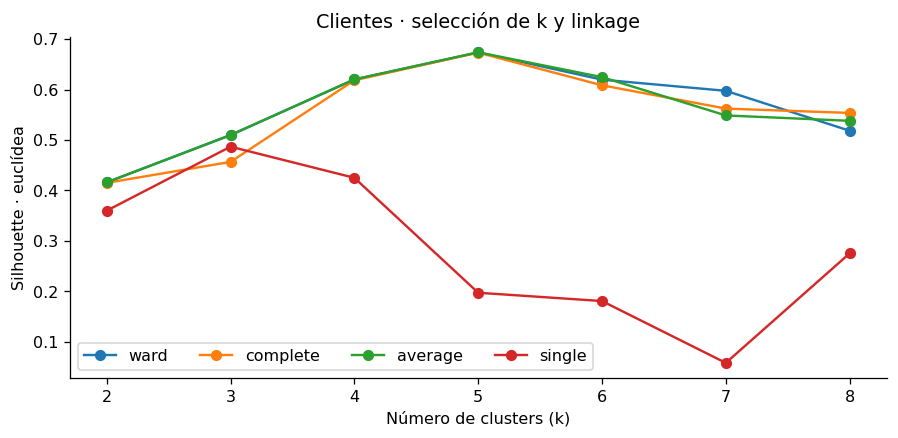

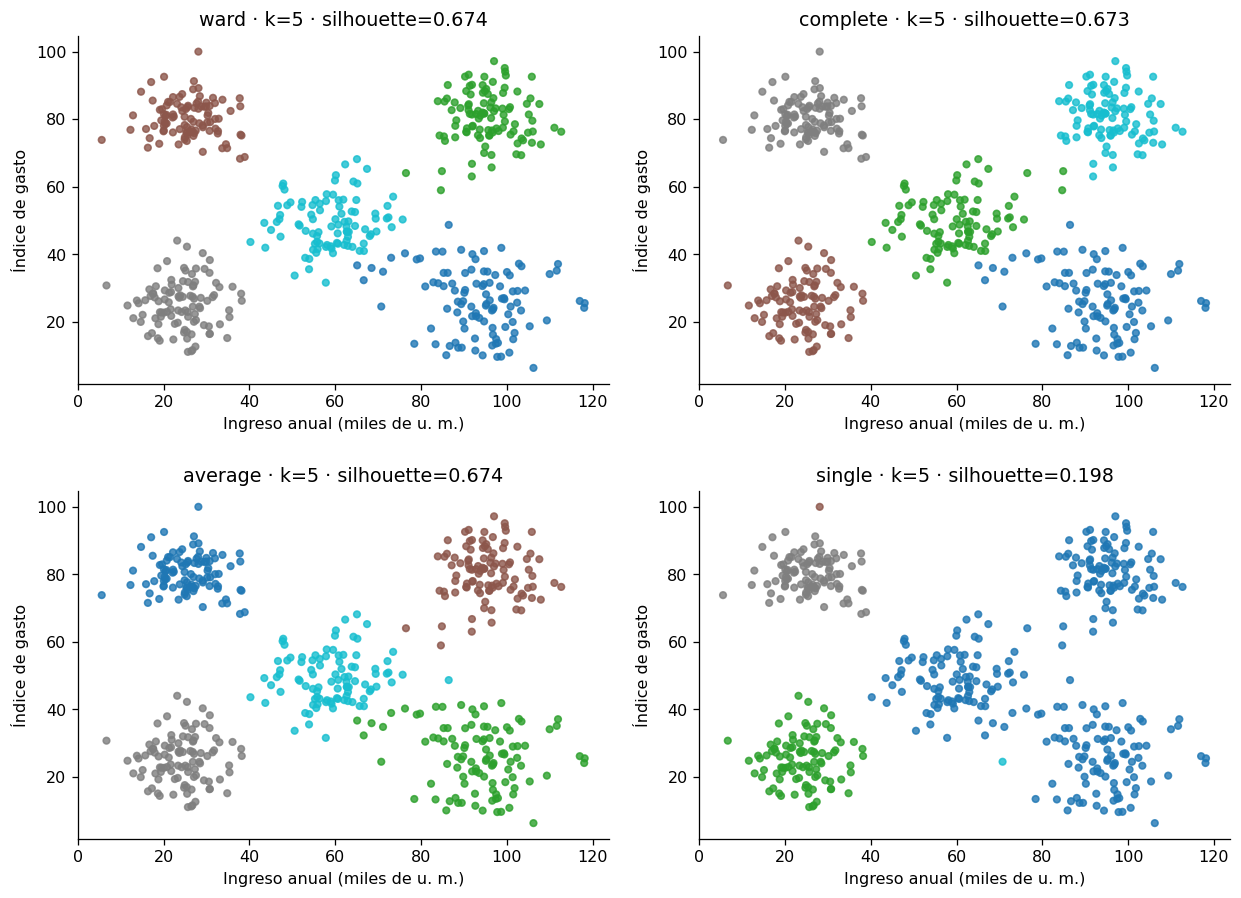

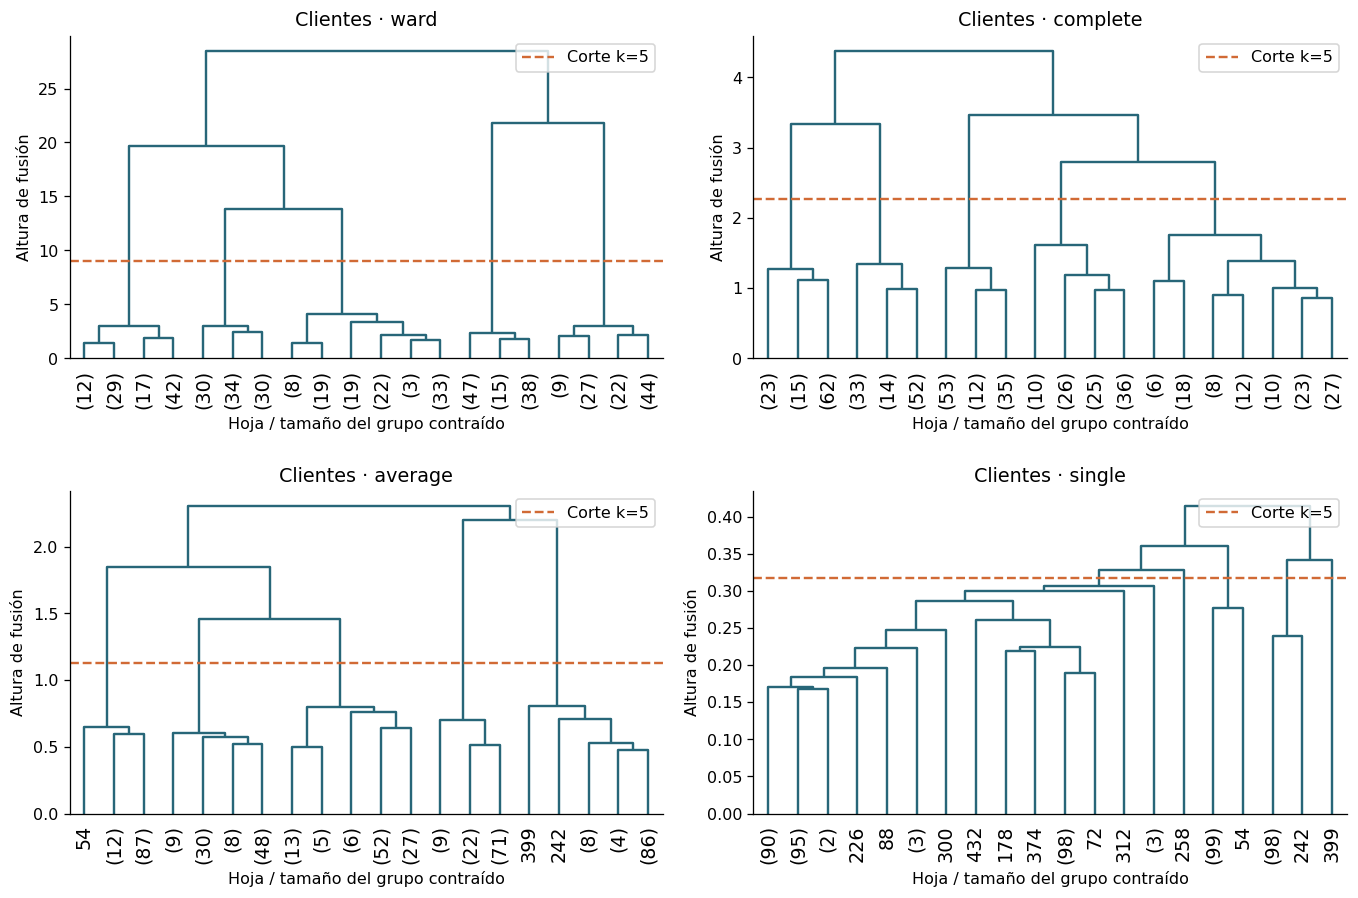

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for method in LINKAGES:
    d = client_results[client_results.linkage == method]
    ax.plot(d.k, d.silhouette, marker='o', label=method)
ax.set(xlabel='Número de clusters (k)', ylabel='Silhouette · euclídea',
       title='Clientes · selección de k y linkage')
ax.legend(ncol=4)
savefig('clientes_seleccion_k.png')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, method in zip(axes.ravel(), LINKAGES):
    labels = client_models[(method, int(best_client.k))].labels_
    ax.scatter(clients.ingreso_anual_miles, clients.indice_gasto,
               c=labels, cmap='tab10', s=17, alpha=0.8)
    row = client_results[(client_results.linkage == method) & (client_results.k == int(best_client.k))].iloc[0]
    ax.set(title=f'{method} · k={int(best_client.k)} · silhouette={row.silhouette:.3f}',
           xlabel='Ingreso anual (miles de u. m.)', ylabel='Índice de gasto')
savefig('clientes_comparacion.png')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, method in zip(axes.ravel(), LINKAGES):
    model = client_models[(method, int(best_client.k))]
    dendrogram(to_linkage(model), truncate_mode='lastp', p=20, leaf_rotation=90,
               ax=ax, color_threshold=0, above_threshold_color='#276678')
    # Línea entre las dos fusiones que delimitan k; alturas propias de cada criterio.
    heights = model.distances_
    k = int(best_client.k)
    cut = (heights[-k] + heights[-(k-1)]) / 2
    ax.axhline(cut, color='#D16A35', linestyle='--', label=f'Corte k={k}')
    ax.set(title=f'Clientes · {method}', ylabel='Altura de fusión',
           xlabel='Hoja / tamaño del grupo contraído')
    ax.legend()
savefig('clientes_dendrogramas.png')

In [10]:
client_profiles = clients.groupby('cluster').agg(
    n=('cliente_id', 'size'), ingreso_medio=('ingreso_anual_miles', 'mean'),
    gasto_medio=('indice_gasto', 'mean')).reset_index()

def describe_client(row):
    income = 'bajo' if row.ingreso_medio < 40 else ('alto' if row.ingreso_medio > 80 else 'medio')
    spending = 'bajo' if row.gasto_medio < 40 else ('alto' if row.gasto_medio > 65 else 'medio')
    if income == 'alto' and spending == 'alto':
        action = 'Evaluar beneficios de fidelización y atención preferente.'
    elif income == 'alto' and spending == 'bajo':
        action = 'Investigar barreras de compra antes de ofrecer promociones.'
    elif income == 'bajo' and spending == 'alto':
        action = 'Evaluar recompensas accesibles; no inferir capacidad crediticia.'
    elif income == 'bajo' and spending == 'bajo':
        action = 'Probar ofertas de entrada y medir su respuesta.'
    else:
        action = 'Probar recomendaciones y promociones moderadas.'
    return pd.Series({'perfil': f'Ingreso {income}, gasto {spending}', 'accion_hipotetica': action})
client_profiles = pd.concat([client_profiles, client_profiles.apply(describe_client, axis=1)], axis=1)
client_profiles.to_csv(OUT / 'clientes_perfiles.csv', index=False)
display(client_profiles.round(2))
client_findings = [
    f'{client_key[0]} con k={client_key[1]} obtiene silhouette={best_client.silhouette:.4f} y Davies–Bouldin={best_client.davies_bouldin:.4f}.',
    f'El ARI frente a los grupos generadores es {best_client.ARI:.4f}; se usa para comprobar recuperación, no para seleccionar el modelo.',
    'Los perfiles corresponden a las medias observadas. Sus nombres y acciones son interpretaciones posteriores al clustering.',
    'La simulación favorece grupos compactos por construcción. Un buen resultado no demuestra eficacia comercial en clientes reales.',
    'Antes de aplicar estas acciones se necesitan datos reales, validación del negocio y seguimiento de resultados.']
runner_up = client_ranking.iloc[1]
client_findings.append(f'La diferencia de silhouette entre la mejor combinación y {runner_up.linkage} con k={int(runner_up.k)} es apenas {best_client.silhouette-runner_up.silhouette:.6f}; es una ventaja numérica pequeña, sin evidencia de superioridad estable.')
display(Markdown('\n'.join('- '+f for f in client_findings)))

,cluster,n,ingreso_medio,gasto_medio,perfil,accion_hipotetica
0,0,100,25.77,80.23,"Ingreso bajo, gasto alto",Evaluar recompensas accesibles; no inferir capacidad crediticia.
1,1,103,93.38,26.02,"Ingreso alto, gasto bajo",Investigar barreras de compra antes de ofrecer promociones.
2,2,102,95.59,80.53,"Ingreso alto, gasto alto",Evaluar beneficios de fidelización y atención preferente.
3,3,100,24.19,25.24,"Ingreso bajo, gasto bajo",Probar ofertas de entrada y medir su respuesta.
4,4,95,59.12,49.27,"Ingreso medio, gasto medio",Probar recomendaciones y promociones moderadas.


- average con k=5 obtiene silhouette=0.6736 y Davies–Bouldin=0.4557.
- El ARI frente a los grupos generadores es 0.9657; se usa para comprobar recuperación, no para seleccionar el modelo.
- Los perfiles corresponden a las medias observadas. Sus nombres y acciones son interpretaciones posteriores al clustering.
- La simulación favorece grupos compactos por construcción. Un buen resultado no demuestra eficacia comercial en clientes reales.
- Antes de aplicar estas acciones se necesitan datos reales, validación del negocio y seguimiento de resultados.
- La diferencia de silhouette entre la mejor combinación y ward con k=5 es apenas 0.000108; es una ventaja numérica pequeña, sin evidencia de superioridad estable.

## 3. Segmentación jerárquica de imágenes
Se usan `china.jpg` y `flower.jpg`, fotografías incluidas en scikit-learn. Se conserva aproximadamente su relación de aspecto al reducirlas a **96 × 64** píxeles.

Cada píxel se representa con cinco valores: `[R, G, B, 0.25·fila, 0.25·columna]`, normalizados a 0–1. Las coordenadas favorecen proximidad espacial. Una matriz de conectividad con cuatro vecinos permite fusionar solo regiones adyacentes. La restricción también modifica el comportamiento de average y complete respecto al caso sin conectividad.

Se comparan **Ward, complete y average** a **6, 12 y 24 regiones**. Se mantiene fija la imagen, la representación y la conectividad. El color reconstruido de cada región es su RGB promedio.

- **MSE RGB ↓:** error de reconstrucción en escala 0–1; no mide identificación de objetos.
- **Silhouette ↑:** sobre una muestra fija de 1 200 píxeles en las cinco variables; diagnóstico geométrico, no criterio de exactitud semántica.
- **Componentes conectados:** verifica que cada región sea espacialmente continua.
- **k:** controla el nivel de detalle. Más regiones suelen reducir el MSE, por lo que se comparan linkages a igual k.

Fuentes: [fotografías de ejemplo](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html), [rejilla de conectividad](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.image.grid_to_graph.html), [ejemplo oficial de Ward para imágenes](https://scikit-learn.org/stable/auto_examples/cluster/plot_coin_ward_segmentation.html).

Créditos: `china.jpg`, por **danielbuechele** (CC BY 2.0); `flower.jpg`, por **vultilion** (CC BY 2.0). Se generan versiones reducidas y segmentadas para esta actividad. [Detalles de origen y atribución](https://github.com/scikit-learn/scikit-learn/tree/main/sklearn/datasets/images).

In [11]:
IMAGE_K = [6, 12, 24]
IMAGE_LINKAGES = ['ward', 'complete', 'average']
H, W = 64, 96
SPATIAL_WEIGHT = 0.25
connectivity = grid_to_graph(n_x=H, n_y=W)
sample_pixels = np.random.default_rng(SEED).choice(H*W, size=1200, replace=False)
image_rows, image_outputs = [], {}
images = {}

def boundary_overlay(rgb, labels2d):
    boundary = np.zeros(labels2d.shape, dtype=bool)
    boundary[1:, :] |= labels2d[1:, :] != labels2d[:-1, :]
    boundary[:, 1:] |= labels2d[:, 1:] != labels2d[:, :-1]
    overlay = rgb.copy()
    overlay[boundary] = [1.0, 0.2, 0.05]
    return overlay

for image_name in ['china.jpg', 'flower.jpg']:
    original = load_sample_image(image_name)
    rgb = np.asarray(Image.fromarray(original).resize((W, H), Image.Resampling.LANCZOS), dtype=float) / 255.0
    images[image_name] = rgb
    rr, cc = np.mgrid[0:H, 0:W]
    features = np.column_stack([rgb.reshape(-1, 3),
                                SPATIAL_WEIGHT*rr.ravel()/(H-1),
                                SPATIAL_WEIGHT*cc.ravel()/(W-1)])
    rgb_flat = rgb.reshape(-1, 3)
    for method in IMAGE_LINKAGES:
        for k in IMAGE_K:
            model = AgglomerativeClustering(n_clusters=k, linkage=method, metric='euclidean',
                                           connectivity=connectivity, compute_full_tree=False)
            t0 = perf_counter()
            labels = model.fit_predict(features)
            elapsed = perf_counter() - t0
            counts = np.bincount(labels)
            means = np.stack([rgb_flat[labels == i].mean(axis=0) for i in range(k)])
            reconstructed = means[labels].reshape(H, W, 3)
            labels2d = labels.reshape(H, W)
            components = [connected_label(labels2d == i)[1] for i in range(k)]
            sample_labels = labels[sample_pixels]
            unique_sample = np.unique(sample_labels).size
            sil = silhouette_score(features[sample_pixels], sample_labels) if 1 < unique_sample < len(sample_labels) else np.nan
            image_rows.append({'imagen': image_name, 'linkage': method, 'k': k,
                               'mse_rgb': float(np.mean((rgb-reconstructed)**2)),
                               'silhouette_muestra': sil,
                               'regiones_en_muestra': unique_sample,
                               'region_min_px': int(counts.min()), 'region_max_px': int(counts.max()),
                               'componentes_totales': int(sum(components)),
                               'max_componentes_por_region': int(max(components)),
                               'segundos_ajuste': elapsed})
            assert len(counts) == k and max(components) == 1
            image_outputs[(image_name, method, k)] = (labels2d, reconstructed)
            np.save(OUT / f'{Path(image_name).stem}_{method}_k{k}_etiquetas.npy', labels2d)
image_results = pd.DataFrame(image_rows)
image_results.to_csv(OUT / 'imagenes_metricas.csv', index=False)
display(image_results.round(5))

,imagen,linkage,k,mse_rgb,silhouette_muestra,regiones_en_muestra,region_min_px,region_max_px,componentes_totales,max_componentes_por_region,segundos_ajuste
0,china.jpg,ward,6,0.01144,0.25902,6,476,1650,6,1,0.11761
1,china.jpg,ward,12,0.00762,0.23912,12,129,1650,12,1,0.11800
2,china.jpg,ward,24,0.00516,0.17976,24,14,890,24,1,0.17758
3,china.jpg,complete,6,0.03650,0.20419,4,2,3355,6,1,0.10249
4,china.jpg,complete,12,0.03307,-0.09266,9,2,3129,12,1,0.09941
5,china.jpg,complete,24,0.03232,-0.12014,18,1,3107,24,1,0.14706
6,china.jpg,average,6,0.10444,-0.36985,5,1,5992,6,1,0.13385
7,china.jpg,average,12,0.02473,0.08433,7,1,3152,12,1,0.10946
8,china.jpg,average,24,0.02406,-0.11500,13,1,3144,24,1,0.11058
9,flower.jpg,ward,6,0.00716,0.20336,6,143,2799,6,1,0.16995


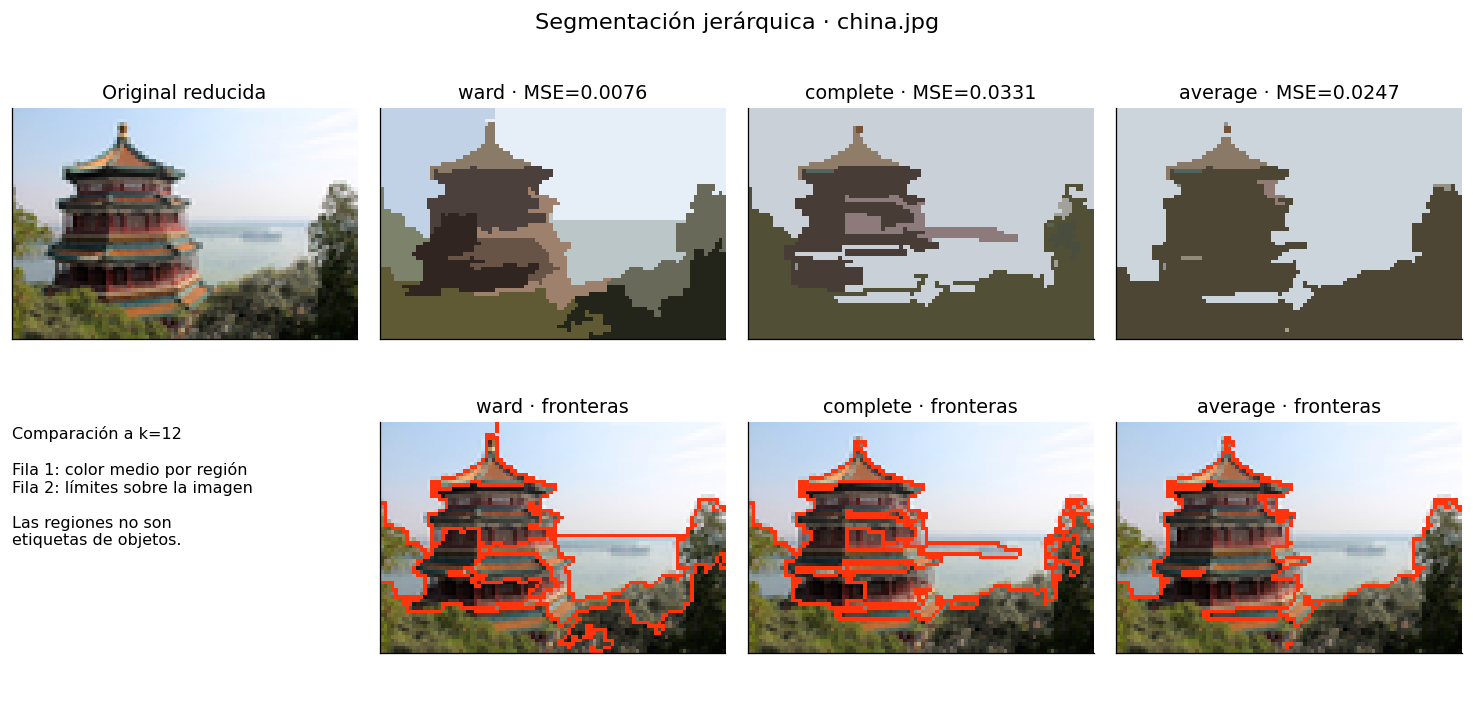

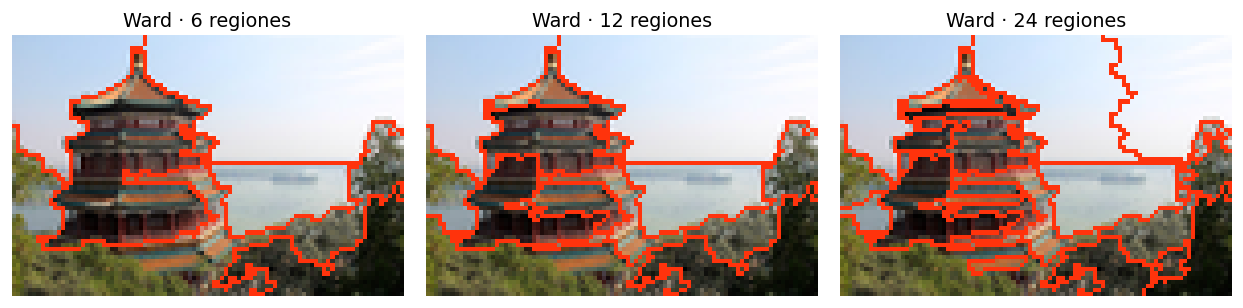

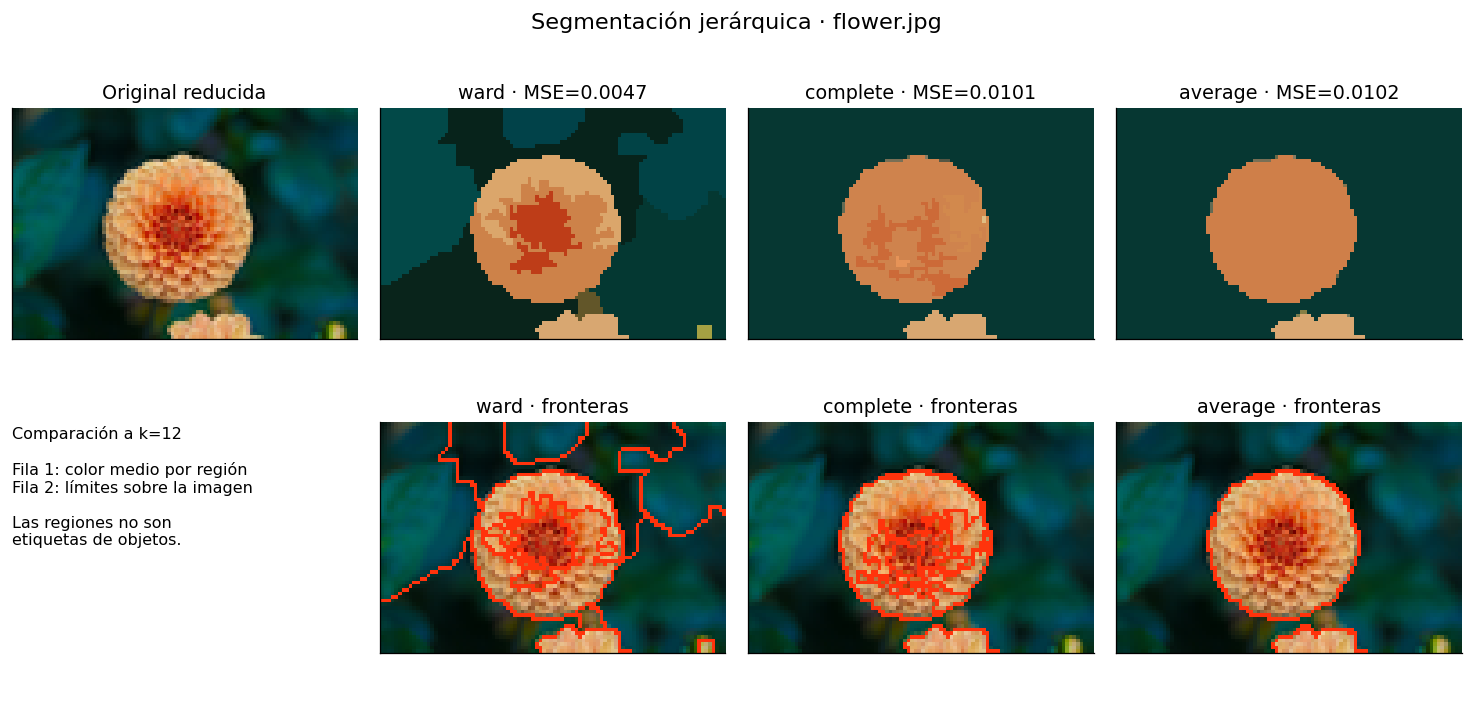

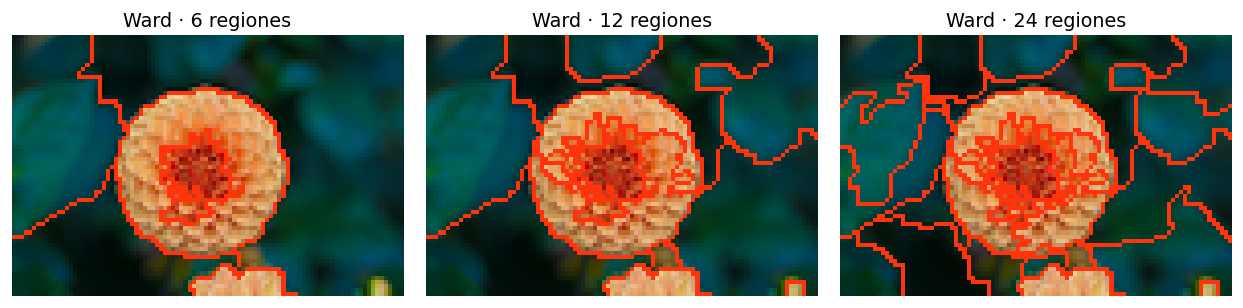

- china.jpg: a k=12, ward tiene el menor MSE RGB (0.00762) entre las tres alternativas.
- flower.jpg: a k=12, ward tiene el menor MSE RGB (0.00474) entre las tres alternativas.
- china.jpg: la mayor silhouette muestreada corresponde a ward (0.2391); su región mayor abarca 26.9%. Debe interpretarse junto con tamaños y fronteras, especialmente cuando existen regiones de uno o dos píxeles.
- flower.jpg: la mayor silhouette muestreada corresponde a average (0.4152); su región mayor abarca 75.8%. Debe interpretarse junto con tamaños y fronteras, especialmente cuando existen regiones de uno o dos píxeles.
- Inspección de china.jpg a k=12: Ward conserva más diferencias de color entre cielo, agua, edificio y vegetación; average fusiona amplias zonas oscuras del edificio y el follaje.
- Inspección de flower.jpg a k=12: los tres métodos delimitan la flor principal. Ward subdivide pétalos y fondo por sus tonalidades; average conserva una silueta más simple. Más detalle cromático no implica una mejor máscara del objeto completo.
- Todas las regiones de todas las configuraciones resultaron conectadas; la conectividad de cuatro vecinos evitó grupos de píxeles aislados entre sí.
- Un menor MSE indica mayor fidelidad de color, pero no demuestra que una región corresponda a una flor, un edificio o un objeto completo.
- La reducción de resolución elimina detalles finos; el peso espacial 0.25 y los valores de k son decisiones didácticas fijas, no parámetros optimizados con máscaras humanas.
- Sin anotaciones de referencia no se reportan ARI ni IoU de segmentación semántica.

In [12]:
for image_name, rgb in images.items():
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.3))
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title('Original reducida')
    axes[1, 0].axis('off')
    axes[1, 0].text(0, 0.85, 'Comparación a k=12\n\nFila 1: color medio por región\nFila 2: límites sobre la imagen\n\nLas regiones no son\netiquetas de objetos.',
                    transform=axes[1, 0].transAxes, va='top', fontsize=10)
    for col, method in enumerate(IMAGE_LINKAGES, start=1):
        labels2d, reconstructed = image_outputs[(image_name, method, 12)]
        axes[0, col].imshow(reconstructed)
        row = image_results[(image_results.imagen == image_name) & (image_results.linkage == method) & (image_results.k == 12)].iloc[0]
        axes[0, col].set_title(f'{method} · MSE={row.mse_rgb:.4f}')
        axes[1, col].imshow(boundary_overlay(rgb, labels2d))
        axes[1, col].set_title(f'{method} · fronteras')
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'Segmentación jerárquica · {image_name}', fontsize=14)
    savefig(f'imagen_{Path(image_name).stem}_comparacion.png')

    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    for ax, k in zip(axes, IMAGE_K):
        labels2d, _ = image_outputs[(image_name, 'ward', k)]
        ax.imshow(boundary_overlay(rgb, labels2d))
        ax.set_title(f'Ward · {k} regiones')
        ax.axis('off')
    savefig(f'imagen_{Path(image_name).stem}_detalle_k.png')

image_at12 = image_results[image_results.k == 12].sort_values(['imagen', 'mse_rgb'])
image_findings = []
for image_name in images:
    winner = image_at12[image_at12.imagen == image_name].iloc[0]
    image_findings.append(f'{image_name}: a k=12, {winner.linkage} tiene el menor MSE RGB ({winner.mse_rgb:.5f}) entre las tres alternativas.')
for image_name in images:
    subset12 = image_at12[image_at12.imagen == image_name]
    leader_sil = subset12.loc[subset12.silhouette_muestra.idxmax()]
    image_findings.append(f'{image_name}: la mayor silhouette muestreada corresponde a {leader_sil.linkage} ({leader_sil.silhouette_muestra:.4f}); su región mayor abarca {leader_sil.region_max_px/(H*W):.1%}. Debe interpretarse junto con tamaños y fronteras, especialmente cuando existen regiones de uno o dos píxeles.')
image_findings.extend([
    'Inspección de china.jpg a k=12: Ward conserva más diferencias de color entre cielo, agua, edificio y vegetación; average fusiona amplias zonas oscuras del edificio y el follaje.',
    'Inspección de flower.jpg a k=12: los tres métodos delimitan la flor principal. Ward subdivide pétalos y fondo por sus tonalidades; average conserva una silueta más simple. Más detalle cromático no implica una mejor máscara del objeto completo.'])
image_findings.extend([
    'Todas las regiones de todas las configuraciones resultaron conectadas; la conectividad de cuatro vecinos evitó grupos de píxeles aislados entre sí.',
    'Un menor MSE indica mayor fidelidad de color, pero no demuestra que una región corresponda a una flor, un edificio o un objeto completo.',
    'La reducción de resolución elimina detalles finos; el peso espacial 0.25 y los valores de k son decisiones didácticas fijas, no parámetros optimizados con máscaras humanas.',
    'Sin anotaciones de referencia no se reportan ARI ni IoU de segmentación semántica.'])
display(Markdown('\n'.join('- '+f for f in image_findings)))

## 4. Resumen ejecutivo y respuestas
La celda siguiente escribe **README.md** con las métricas de esta ejecución, los perfiles encontrados, figuras y referencias. Puede subirse a GitHub junto con `resultados/` y el notebook. No publica nada automáticamente.

Si no pudo descargarse Newsgroups, el README indica **pendiente** para texto y no declara completados los 20 puntos. Tras ejecutar con internet, se actualiza con los resultados reales. No se rellenan cifras esperadas como si fueran mediciones.

In [13]:
references = """## Referencias
- Scikit-learn. [Clustering jerárquico y criterios de enlace](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering).
- Scikit-learn. [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html).
- Scikit-learn. [20 Newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html).
- Scikit-learn. [TF–IDF y LSA para clustering de documentos](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html).
- Scikit-learn. [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html).
- Scikit-learn. [load_sample_image](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html).
- Scikit-learn. [Segmentación de imágenes con Ward](https://scikit-learn.org/stable/auto_examples/cluster/plot_coin_ward_segmentation.html).
- Scikit-learn. [grid_to_graph](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.image.grid_to_graph.html).
- [Créditos originales de las fotografías](https://github.com/scikit-learn/scikit-learn/tree/main/sklearn/datasets/images). `china.jpg`: danielbuechele; `flower.jpg`: vultilion. CC BY 2.0. Se muestran versiones reducidas y segmentadas.
"""
readme = f"""# Actividad 08 — Clustering jerárquico
**Unidad II · Machine Learning I**  
**Autora:** Jaqueline Rocio Ramos Vargas · Trabajo individual

## Resumen ejecutivo
Se aplica agrupamiento aglomerativo a documentos, clientes simulados y fotografías. Se comparan linkages manteniendo las mismas variables, distancias y muestras dentro de cada ejercicio.

| Ejercicio | Estado de esta ejecución | Evidencia |
|---|---|---|
| Texto — 6 puntos | {'Ejecutado' if text_results is not None else 'PENDIENTE DE EJECUCIÓN: descarga no disponible'} | Notebook, métricas y términos por grupo cuando se descarga el corpus |
| Clientes — 6 puntos | Ejecutado | 28 combinaciones de cuatro linkages y k=2…8; perfiles |
| Imágenes — 6 puntos | Ejecutado | 18 combinaciones: dos fotografías, tres linkages, tres k |
| Resumen — 2 puntos | Este README | Código en notebook, tablas, hallazgos y referencias |

## Cómo ejecutar y entregar
1. Abrir `Actividad_08_Clustering_Jerarquico.ipynb` en Google Colab mediante **Archivo → Subir notebook**.
2. Usar CPU, conexión a internet y **Entorno de ejecución → Ejecutar todas**. No requiere GPU ni cuenta Kaggle.
3. Comprobar que la última verificación indique los tres ejercicios ejecutados.
4. Descargar `Actividad_08_resultados.zip` desde el panel de archivos de Colab y guardar el notebook con sus salidas mediante **Archivo → Descargar → Descargar .ipynb**.
5. Para GitHub, subir el notebook, este README y la carpeta `resultados/` juntos; así se muestran las figuras. Esta entrega no crea un repositorio automáticamente.

También se incluye `solucion_actividad08.py`, con las mismas celdas de código, para ejecución local. Instalar `requirements.txt` y ejecutar `python solucion_actividad08.py` desde la carpeta del proyecto. Las versiones efectivas se guardan en `resultados/entorno.json`. El ZIP que genera el notebook contiene resultados y README; guardar el notebook por separado.

## Diseño y criterios de éxito
El clustering es aglomerativo: fusiona grupos hasta construir una jerarquía. Single usa la menor distancia entre puntos; complete la mayor; average el promedio; Ward minimiza el incremento de dispersión interna y requiere distancia euclídea. Las alturas de distintos linkages no son directamente intercambiables.

- **Texto:** mayor ARI a k=20; V-measure como desempate. Evaluación exploratoria sobre la misma muestra, sin afirmaciones sobre generalización.
- **Clientes:** mayor silhouette; desempate por menor Davies–Bouldin y menor k. ARI sintético solo como evaluación posterior.
- **Imágenes:** menor MSE a igual k para fidelidad RGB, más inspección de fronteras; no equivale a mejor segmentación semántica.

ARI=1 significa coincidencia perfecta de particiones; cerca de 0 es el nivel esperado por azar. V-measure y silhouette se maximizan; Davies–Bouldin se minimiza. Los números de cluster son identificadores arbitrarios.

## 1. Texto — 20 Newsgroups
Se solicitan 100 documentos de cada una de las 20 categorías del subconjunto train. Se eliminan cabeceras, pies, citas, textos muy cortos y duplicados exactos normalizados. Se aplica TF–IDF (hasta 15 000 términos), SVD de 100 componentes y normalización L2. Los cuatro linkages reciben la misma matriz y distancia euclídea.

Las etiquetas se usan para estratificar y evaluar; no se incluyen como características. Fijar k=20 y seleccionar por ARI usa conocimiento de las categorías, por lo que no constituye una selección totalmente no supervisada. La muestra reduce el costo cuadrático; no representa una ejecución sobre los 18 846 documentos completos.

"""
if text_results is not None:
    cols = ['linkage', 'k', 'ARI', 'V_measure', 'silhouette', 'davies_bouldin', 'min_n', 'max_n']
    readme += table_md(text_results[cols]) + '\n\n### Hallazgos y mejor linkage\n' + '\n'.join('- '+f for f in text_findings)
    readme += '\n\n### Temas encontrados\n' + table_md(text_profiles)
    readme += '\n\n![Jerarquías de texto](resultados/figuras/texto_dendrogramas.png)\n\n![Categorías y clusters](resultados/figuras/texto_contingencia.png)\n'
else:
    readme += f'**PENDIENTE:** {text_status}. El código está implementado, pero no se dispone de métricas, ganador ni hallazgos empíricos de texto en esta ejecución. Ejecutar el notebook con acceso al corpus para completar este apartado.\n'
readme += '\n## 2. Segmentación de clientes\n'
readme += 'Se generan 500 clientes con cinco centros mediante make_blobs (semilla 42), usando ingreso anual e índice de gasto. Se estandarizan las variables. Los datos son sintéticos y su estructura compacta favorece ciertos linkages; no se presentan como datos de Mall Customers ni evidencia de eficacia comercial.\n\n'
readme += '### Mejor k por linkage según silhouette\n'
readme += table_md(client_ranking.groupby('linkage', sort=False).head(1)[['linkage', 'k', 'silhouette', 'davies_bouldin', 'ARI', 'min_n', 'max_n']])
readme += '\n\n### Comparación a igual k seleccionado\n'
readme += table_md(client_results[client_results.k == int(best_client.k)][['linkage', 'k', 'silhouette', 'davies_bouldin', 'ARI']])
readme += '\n\n### Hallazgos\n' + '\n'.join('- '+f for f in client_findings)
readme += '\n\n### Perfiles y acciones hipotéticas\n' + table_md(client_profiles, 2)
readme += '\n\nLos umbrales para nombrar los perfiles son didácticos: ingreso bajo <40, alto >80; gasto bajo <40, alto >65. No intervienen en el ajuste del clustering.\n'
readme += '\n![Selección de k](resultados/figuras/clientes_seleccion_k.png)\n\n![Comparación de clientes](resultados/figuras/clientes_comparacion.png)\n\n![Jerarquías de clientes](resultados/figuras/clientes_dendrogramas.png)\n'
readme += '\n## 3. Segmentación de imágenes\n'
readme += 'Se segmentan china.jpg y flower.jpg a 96×64 píxeles. Características: RGB en 0–1 y coordenadas normalizadas con peso 0.25. Conectividad de cuatro vecinos. Se comparan Ward, complete y average a 6, 12 y 24 regiones.\n\n'
readme += '### Comparación a 12 regiones\n' + table_md(image_at12[['imagen', 'linkage', 'k', 'mse_rgb', 'silhouette_muestra', 'region_min_px', 'region_max_px']], 5)
readme += '\n\n### Hallazgos\n' + '\n'.join('- '+f for f in image_findings)
readme += '\n\nLa silhouette usa la misma muestra de 1 200 píxeles para todas las configuraciones; puede omitir regiones muy pequeñas. `regiones_en_muestra` permite detectarlo. Las fronteras y la conectividad se verifican sobre los 6 144 píxeles completos.\n'
for name in ['china', 'flower']:
    readme += f'\n![Segmentación {name}](resultados/figuras/imagen_{name}_comparacion.png)\n\n![Detalle por k {name}](resultados/figuras/imagen_{name}_detalle_k.png)\n'
readme += """
## Conclusiones y limitaciones
El linkage cambia las fusiones y, por tanto, los tamaños y la composición de los grupos. No hay un criterio universalmente superior: la comparación debe vincularse a la representación, la distancia y el objetivo de cada ejercicio. La jerarquía permite inspeccionar varios niveles de detalle.

El éxito de los clientes simulados no implica éxito en documentos o fotografías. En texto se necesita coherencia temática; en clientes, utilidad y estabilidad de los perfiles; en imágenes, continuidad y correspondencia visual. Una métrica geométrica favorable no garantiza estas propiedades por sí sola.

Se utiliza una sola semilla y no se estima estabilidad entre muestras. No hay evaluación predictiva en un conjunto independiente; AgglomerativeClustering no proporciona directamente `predict` para observaciones nuevas. La palabra «mejor» se limita a las alternativas evaluadas y al criterio declarado.

## Archivos de resultados
- `texto_metricas.csv`, `texto_perfiles.csv`, `texto_contingencia.csv`, `texto_asignaciones.csv` y `texto_auditoria.json`: se generan cuando se ejecuta el corpus real.
- `clientes_metricas.csv`, `clientes_sinteticos.csv`, `clientes_perfiles.csv`.
- `imagenes_metricas.csv` y mapas `*_etiquetas.npy` (cada entero identifica una región).
- `figuras/`: dendrogramas, perfiles visuales y segmentaciones.
- `entorno.json`: versiones y semilla.

"""
executive = '\n### Resultados principales de esta ejecución\n'
if text_results is not None:
    r = text_results.iloc[0]
    executive += f'- **Texto:** {r.linkage}, ARI={r.ARI:.4f}; correspondencia limitada con las 20 categorías. Ward obtiene mayor V-measure en la ejecución de referencia.\n'
executive += f'- **Clientes:** {best_client.linkage}, k={int(best_client.k)}, silhouette={best_client.silhouette:.4f}; ventaja muy pequeña sobre la segunda combinación.\n'
executive += '- **Imágenes:** ' + ' '.join(image_findings[:2]) + ' El criterio es fidelidad del color, no exactitud semántica.\n'
readme = readme.replace('## Cómo ejecutar y entregar', executive + '\n## Cómo ejecutar y entregar')
readme += references
readme = re.sub(r'^(#{1,6} .+)\n(?=\S)', r'\1\n\n', readme, flags=re.MULTILINE)
Path('README.md').write_text(readme, encoding='utf-8')
print('README.md actualizado con los resultados disponibles.')
display(Markdown('### Resumen de resultados\n' + '\n'.join('- '+f for f in client_findings[:2] + image_findings[:2])))

README.md actualizado con los resultados disponibles.


### Resumen de resultados
- average con k=5 obtiene silhouette=0.6736 y Davies–Bouldin=0.4557.
- El ARI frente a los grupos generadores es 0.9657; se usa para comprobar recuperación, no para seleccionar el modelo.
- china.jpg: a k=12, ward tiene el menor MSE RGB (0.00762) entre las tres alternativas.
- flower.jpg: a k=12, ward tiene el menor MSE RGB (0.00474) entre las tres alternativas.

In [14]:
# Verificaciones de integridad: cada observación tiene grupo y cada región es conexa.
assert len(clients) == 500 and clients.cluster.notna().all()
assert len(client_results) == 4*7
assert len(image_results) == 2*3*3
assert (image_results.componentes_totales == image_results.k).all()
if text_results is not None:
    assert len(text_results) == 4
    assert all(len(m.labels_) == len(X_text) for m in text_models.values())
    assert all(np.unique(m.labels_).size == 20 for m in text_models.values())
    print('VERIFICADO: texto, clientes e imágenes ejecutados; README actualizado.')
else:
    print('VERIFICADO: clientes e imágenes. PENDIENTE: ejecutar el apartado de texto con acceso a Newsgroups.')

import zipfile
with zipfile.ZipFile('Actividad_08_resultados.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('README.md')
    for file in sorted(OUT.rglob('*')):
        if file.is_file():
            z.write(file)
print('Descargar Actividad_08_resultados.zip desde el panel de archivos de Colab.')
# Opcional en Colab (descomentar):
# from google.colab import files
# files.download('Actividad_08_resultados.zip')

VERIFICADO: texto, clientes e imágenes ejecutados; README actualizado.
Descargar Actividad_08_resultados.zip desde el panel de archivos de Colab.


### Preguntas para la exposición
1. **¿Qué cambió al usar otros linkages?** La regla de fusión; por eso cambian los grupos aunque las variables sean iguales.
2. **¿Por qué estandarizar los clientes?** Para equilibrar la influencia de las dos escalas en la distancia.
3. **¿Por qué fijar conectividad en imágenes?** Para obtener regiones continuas mediante fusiones entre vecinos.
4. **¿Un cluster siempre es una clase u objeto?** No. Es un conjunto definido por semejanza; su significado necesita interpretación.
5. **¿Qué linkage ganó?** Consultar las tablas ejecutadas y mencionar el criterio: ARI en texto, silhouette en clientes y MSE a igual k para fidelidad de color en imágenes.
6. **¿Cómo leer un dendrograma?** De las hojas a la raíz: las uniones muestran fusiones y la altura expresa el costo o distancia según el linkage; el corte determina la cantidad de grupos.